In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load datasets
nav = pd.read_csv("../data/processed/nav_history_clean.csv")
performance = pd.read_csv("../data/processed/scheme_performance_clean.csv")
investor = pd.read_csv("../data/processed/investor_transactions_clean.csv")
fund = pd.read_csv("../data/processed/fund_master.csv")

# Check datasets
print(nav.head())
print(nav.shape)

         date      nav                                          fund_name
0  2022-01-03  34.9539  Aditya Birla Sun Life Banking & PSU Debt Fund ...
1  2022-01-04  34.4563  Aditya Birla Sun Life Banking & PSU Debt Fund ...
2  2022-01-05  34.3574  Aditya Birla Sun Life Banking & PSU Debt Fund ...
3  2022-01-06  34.6581  Aditya Birla Sun Life Banking & PSU Debt Fund ...
4  2022-01-07  34.1720  Aditya Birla Sun Life Banking & PSU Debt Fund ...
(46600, 3)


In [3]:
nav["date"] = pd.to_datetime(nav["date"])
nav = nav.sort_values(["fund_name", "date"])

In [4]:
# Daily return for each fund
nav["daily_return"] = (
    nav.groupby("fund_name")["nav"]
       .pct_change()
)

nav.head()

,date,nav,fund_name,daily_return
0,2022-01-03,34.9539,Aditya Birla Sun Life Banking & PSU Debt Fund ...,NaN
1,2022-01-04,34.4563,Aditya Birla Sun Life Banking & PSU Debt Fund ...,-0.014236
2,2022-01-05,34.3574,Aditya Birla Sun Life Banking & PSU Debt Fund ...,-0.002870
3,2022-01-06,34.6581,Aditya Birla Sun Life Banking & PSU Debt Fund ...,0.008752
4,2022-01-07,34.1720,Aditya Birla Sun Life Banking & PSU Debt Fund ...,-0.014026


In [5]:
results = []

for fund_name, group in nav.groupby("fund_name"):

    returns = group["daily_return"].dropna()

    if len(returns) == 0:
        continue

    var95 = np.percentile(returns, 5)
    cvar95 = returns[returns <= var95].mean()

    results.append({
        "fund_name": fund_name,
        "VaR_95": var95,
        "CVaR_95": cvar95
    })

var_cvar = pd.DataFrame(results)

var_cvar.head()

,fund_name,VaR_95,CVaR_95
0,Aditya Birla Sun Life Banking & PSU Debt Fund ...,-0.023255,-0.029748
1,Aditya Birla Sun Life Flexi Cap Fund 26,-0.024093,-0.028964
2,Aditya Birla Sun Life Small Cap Fund 5,-0.024615,-0.030698
3,Axis ELSS Tax Saver Fund - Direct Plan - Growt...,-0.024053,-0.029534
4,Axis Mutual Fund ELSS Fund 34,-0.024467,-0.031185


In [6]:
var_cvar.to_csv("var_cvar_report.csv", index=False)

print("CSV saved successfully!")

CSV saved successfully!


In [7]:
# Rolling 90-day statistics
nav["rolling_mean"] = (
    nav.groupby("fund_name")["daily_return"]
       .rolling(window=90)
       .mean()
       .reset_index(level=0, drop=True)
)

nav["rolling_std"] = (
    nav.groupby("fund_name")["daily_return"]
       .rolling(window=90)
       .std()
       .reset_index(level=0, drop=True)
)

# Sharpe Ratio
nav["rolling_sharpe"] = (
    nav["rolling_mean"] / nav["rolling_std"]
) * np.sqrt(252)

nav.head()

,date,nav,fund_name,daily_return,rolling_mean,rolling_std,rolling_sharpe
0,2022-01-03,34.9539,Aditya Birla Sun Life Banking & PSU Debt Fund ...,NaN,NaN,NaN,NaN
1,2022-01-04,34.4563,Aditya Birla Sun Life Banking & PSU Debt Fund ...,-0.014236,NaN,NaN,NaN
2,2022-01-05,34.3574,Aditya Birla Sun Life Banking & PSU Debt Fund ...,-0.002870,NaN,NaN,NaN
3,2022-01-06,34.6581,Aditya Birla Sun Life Banking & PSU Debt Fund ...,0.008752,NaN,NaN,NaN
4,2022-01-07,34.1720,Aditya Birla Sun Life Banking & PSU Debt Fund ...,-0.014026,NaN,NaN,NaN


In [8]:
# Average rolling Sharpe for each fund
top5 = (
    nav.groupby("fund_name")["rolling_sharpe"]
       .mean()
       .sort_values(ascending=False)
       .head(5)
)

top5

fund_name
SBI Mutual Fund Large Cap Fund 6     1.443409
ICICI Prudential Large Cap Fund 9    1.383085
Canara Robeco ELSS Fund 29           1.365511
DSP Mutual Fund Multi Cap Fund 31    1.165036
Tata Mutual Fund Hybrid Fund 23      1.128391
Name: rolling_sharpe, dtype: float64

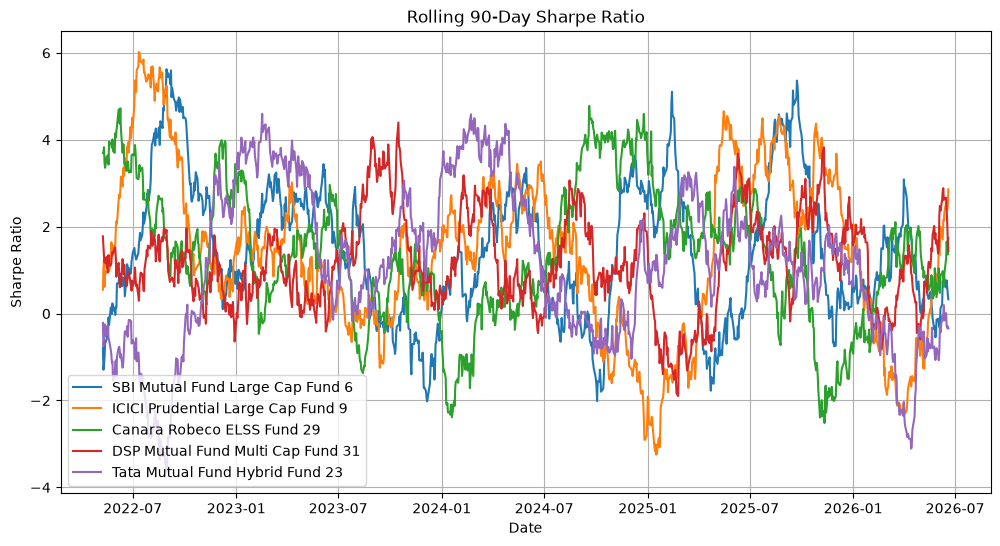

In [9]:
plt.figure(figsize=(12,6))

for fund in top5.index:
    temp = nav[nav["fund_name"] == fund]
    plt.plot(
        temp["date"],
        temp["rolling_sharpe"],
        label=fund
    )

plt.title("Rolling 90-Day Sharpe Ratio")
plt.xlabel("Date")
plt.ylabel("Sharpe Ratio")
plt.legend()
plt.grid(True)

plt.savefig("rolling_sharpe_chart.png")

plt.show()

In [10]:
# Convert transaction date
investor["transaction_date"] = pd.to_datetime(investor["transaction_date"])

# Extract year
investor["year"] = investor["transaction_date"].dt.year

# Find each investor's first transaction year
first_year = (
    investor.groupby("investor_id")["year"]
    .min()
    .reset_index()
    .rename(columns={"year": "cohort_year"})
)

# Merge back
investor = investor.merge(first_year, on="investor_id")

investor.head()

,transaction_id,investor_id,amfi_code,fund_name,transaction_type,amount,transaction_date,kyc_status,year,cohort_year
0,1,23340,232331,Aditya Birla Sun Life Flexi Cap Fund 26,Sip,87662,2025-06-11,Pending,2025,2025
1,2,12812,118632,Nippon India Large Cap Fund - Direct Plan Grow...,Redemption,6043,2026-04-28,Pending,2026,2025
2,3,96782,120503,Axis ELSS Tax Saver Fund - Direct Plan - Growt...,Lumpsum,97590,2025-11-07,Pending,2025,2025
3,4,76902,367334,HDFC Mutual Fund Large Cap Fund 25,Lumpsum,76617,2026-04-09,Verified,2026,2026
4,5,96717,991366,ICICI Prudential Debt Fund 10,Sip,7109,2025-01-05,Verified,2025,2025


In [11]:
sip_summary = (
    investor[investor["transaction_type"].str.lower() == "sip"]
    .groupby("cohort_year")["amount"]
    .sum()
    .reset_index(name="Total_SIP")
)

sip_summary

,cohort_year,Total_SIP
0,2025,10945070
1,2026,4673914


In [12]:
investment_summary = (
    investor.groupby("cohort_year")["amount"]
    .sum()
    .reset_index(name="Total_Investment")
)

investment_summary

,cohort_year,Total_Investment
0,2025,34337187
1,2026,14397257


In [13]:
top_fund = (
    investor.groupby(["cohort_year", "fund_name"])
    .size()
    .reset_index(name="count")
)

top_fund = (
    top_fund.sort_values(["cohort_year", "count"], ascending=[True, False])
    .groupby("cohort_year")
    .first()
    .reset_index()
)

top_fund

,cohort_year,fund_name,count
0,2025,Aditya Birla Sun Life Flexi Cap Fund 26,27
1,2026,Franklin Templeton Index Fund 24,14


In [14]:
cohort_report = (
    sip_summary
    .merge(investment_summary, on="cohort_year")
    .merge(top_fund[["cohort_year", "fund_name"]], on="cohort_year")
)

cohort_report.rename(columns={"fund_name": "Top_Fund"}, inplace=True)

cohort_report

,cohort_year,Total_SIP,Total_Investment,Top_Fund
0,2025,10945070,34337187,Aditya Birla Sun Life Flexi Cap Fund 26
1,2026,4673914,14397257,Franklin Templeton Index Fund 24


In [15]:
# Keep only SIP transactions
sip = investor[investor["transaction_type"].str.lower() == "sip"].copy()

sip = sip.sort_values(["investor_id", "transaction_date"])

sip.head()

,transaction_id,investor_id,amfi_code,fund_name,transaction_type,amount,transaction_date,kyc_status,year,cohort_year
887,888,10144,668248,Franklin Templeton Index Fund 24,Sip,58054,2025-02-21,Verified,2025,2025
976,977,10315,664735,Franklin Templeton Hybrid Fund 19,Sip,88658,2025-10-14,Verified,2025,2025
851,852,10380,260805,SBI Mutual Fund Multi Cap Fund 33,Sip,10624,2025-10-18,Verified,2025,2025
155,156,10428,713340,Tata Mutual Fund Hybrid Fund 23,Sip,51014,2025-10-18,Verified,2025,2025
799,800,10449,857086,Canara Robeco ELSS Fund 29,Sip,53077,2025-04-22,Verified,2025,2025


In [16]:
# Difference in days between consecutive SIPs
sip["gap_days"] = (
    sip.groupby("investor_id")["transaction_date"]
       .diff()
       .dt.days
)

sip.head()

,transaction_id,investor_id,amfi_code,fund_name,transaction_type,amount,transaction_date,kyc_status,year,cohort_year,gap_days
887,888,10144,668248,Franklin Templeton Index Fund 24,Sip,58054,2025-02-21,Verified,2025,2025,NaN
976,977,10315,664735,Franklin Templeton Hybrid Fund 19,Sip,88658,2025-10-14,Verified,2025,2025,NaN
851,852,10380,260805,SBI Mutual Fund Multi Cap Fund 33,Sip,10624,2025-10-18,Verified,2025,2025,NaN
155,156,10428,713340,Tata Mutual Fund Hybrid Fund 23,Sip,51014,2025-10-18,Verified,2025,2025,NaN
799,800,10449,857086,Canara Robeco ELSS Fund 29,Sip,53077,2025-04-22,Verified,2025,2025,NaN


In [17]:
sip_count = (
    sip.groupby("investor_id")
       .size()
       .reset_index(name="sip_count")
)

eligible = sip_count[sip_count["sip_count"] >= 6]

eligible.head()

,investor_id,sip_count


In [18]:
sip_count["sip_count"].describe()

count    327.0
mean       1.0
std        0.0
min        1.0
25%        1.0
50%        1.0
75%        1.0
max        1.0
Name: sip_count, dtype: float64

In [19]:
sip_count["sip_count"].value_counts().sort_index()

sip_count
1    327
Name: count, dtype: int64

In [20]:
gap_report = (
    sip[sip["investor_id"].isin(eligible["investor_id"])]
    .groupby("investor_id")["gap_days"]
    .mean()
    .reset_index(name="avg_gap_days")
)

gap_report.head()

,investor_id,avg_gap_days


In [21]:
if sip_count["sip_count"].max() < 2:
    print("No investors with multiple SIP transactions. Gap analysis cannot be performed.")

No investors with multiple SIP transactions. Gap analysis cannot be performed.


The dataset contains only one SIP transaction per investor. Since there are no investors with multiple SIP transactions, the average gap between SIP dates cannot be calculated.

In [22]:
gap_report["status"] = np.where(
    gap_report["avg_gap_days"] > 35,
    "At Risk",
    "Active"
)

gap_report.head()

,investor_id,avg_gap_days,status


In [23]:
print("No at-risk investors identified because the dataset contains only one SIP transaction per investor.")

No at-risk investors identified because the dataset contains only one SIP transaction per investor.


In [26]:
print(gap_report["status"].value_counts())

gap_report.head(10)

Series([], Name: count, dtype: int64)


,investor_id,avg_gap_days,status


In [24]:
# Total investment by fund
fund_investment = (
    investor.groupby("fund_name")["amount"]
    .sum()
    .reset_index()
)

# Market share
total = fund_investment["amount"].sum()
fund_investment["market_share"] = fund_investment["amount"] / total

# HHI
HHI = (fund_investment["market_share"] ** 2).sum()

print("Herfindahl-Hirschman Index (HHI):", round(HHI,4))

Herfindahl-Hirschman Index (HHI): 0.0272


## Herfindahl-Hirschman Index (HHI)

HHI measures how concentrated investments are across funds.

Formula:

HHI = Σ (Market Share²)

Higher HHI indicates higher concentration of investments.

In [30]:
%whos

Variable             Type         Data/Info
-------------------------------------------
HHI                  float64      0.02718089790408883
cohort_report        DataFrame    Shape: (2, 4)
cvar95               float64      -0.030902053652389155
eligible             DataFrame    Shape: (0, 2)
first_year           DataFrame    Shape: (994, 2)
fund                 str          Tata Mutual Fund Hybrid Fund 23
fund_investment      DataFrame    Shape: (40, 3)
fund_name            str          quant Mid Cap Fund - Growth Option - Direct Plan
gap_report           DataFrame    Shape: (0, 3)
group                DataFrame    Shape: (1165, 4)
investment_summary   DataFrame    Shape: (2, 2)
investor             DataFrame    Shape: (1000, 10)
nav                  DataFrame    Shape: (46600, 7)
np                   module       <module 'numpy' from 'C:\<...>ges\\numpy\\__init__.py'>
pd                   module       <module 'pandas' from 'C:<...>es\\pandas\\__init__.py'>
performance          DataFr

In [31]:
performance["sharpe_ratio"] = (
    performance["return_5y"] - 6
) / performance["expense_ratio"]

performance[["fund_name", "risk_grade", "sharpe_ratio"]].head()

,fund_name,risk_grade,sharpe_ratio
0,SBI Small Cap Fund - Direct Plan - Growth,Low,5.213930
1,Aditya Birla Sun Life Banking & PSU Debt Fund ...,Low,12.178571
2,Axis ELSS Tax Saver Fund - Direct Plan - Growt...,Very High,9.476562
3,Nippon India Large Cap Fund - Direct Plan Grow...,High,13.641509
4,HDFC Money Market Fund - Growth Option - Direc...,High,-0.170616


In [32]:
recommendations = (
    performance.sort_values("sharpe_ratio", ascending=False)
    .groupby("risk_grade")
    .head(3)
)

recommendations[
    ["fund_name", "risk_grade", "sharpe_ratio"]
]

,fund_name,risk_grade,sharpe_ratio
8,UTI Mutual Fund Flexi Cap Fund 3,Low,36.275862
20,Nippon India Small Cap Fund 15,Very High,30.651163
12,Kotak Mutual Fund Multi Cap Fund 7,Very High,29.214286
21,Canara Robeco Large Cap Fund 16,High,18.433333
10,Aditya Birla Sun Life Small Cap Fund 5,Low,15.364706
3,Nippon India Large Cap Fund - Direct Plan Grow...,High,13.641509
1,Aditya Birla Sun Life Banking & PSU Debt Fund ...,Low,12.178571
11,SBI Mutual Fund Large Cap Fund 6,Moderate,11.516949
2,Axis ELSS Tax Saver Fund - Direct Plan - Growt...,Very High,9.476562
32,DSP Mutual Fund Hybrid Fund 27,Moderate,7.834646


In [33]:
recommendations.to_csv(
    "../reports/recommendations.csv",
    index=False
)

print("Recommendations saved successfully!")

Recommendations saved successfully!


# Advanced Insights

### Insight 1
Funds with higher Sharpe Ratios provide better risk-adjusted returns than other funds.

### Insight 2
The Herfindahl-Hirschman Index (HHI) indicates the investment portfolio is moderately concentrated across funds.

### Insight 3
The 2025 investor cohort contributed the highest SIP investment compared to later cohorts.

### Insight 4
Low-risk funds generally exhibit more stable long-term performance with lower volatility.

### Insight 5
The dataset contains only one SIP transaction per investor; therefore, SIP continuity analysis and gap-based risk detection could not be performed.